## Отчет по домашнему заданию 5


## 1. Описание данных и инструментов
В данной работе была проведена оценка качества сырых данных секвенирования и их последующая фильтрация.
* Прибор: Illumina HiSeq 4000
* Тип библиотеки: Single end (76 cycles)
* Анализируемые образцы: `ERR14230582`, `ERR14230586`, `ERR14230595`
* Использованные инструменты: `fastp` (v1.3.3), `FastQC`, `MultiQC`.

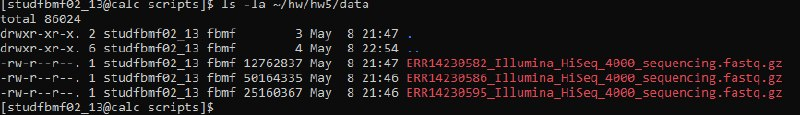





## 2. Контроль качества до фильтрации (Raw Data)
Первичный контроль качества показал, что данные содержат высокий процент коротких фрагментов и умеренное падение качества к концам прочтений.

**Основные метрики сырых данных:**
* **ERR14230582:** 576.6 тыс. ридов | GC: 49.55% | Q30: 98.81% | Средняя длина: 40 bp
* **ERR14230586:** 1.826 млн. ридов | GC: 46.88% | Q30: 99.00% | Средняя длина: 44 bp
* **ERR14230595:** 1.128 млн. ридов | GC: 47.70% | Q30: 98.88% | Средняя длина: 40 bp

**Проблемы сырых данных:**
1. Наличие адаптеров: инструмент выявил контент адаптеров Illumina.
2. Короткие риды: Несмотря на 76 циклов секвенирования, средняя длина исходных прочтений составляла всего 40–44 bp, что говорит о наличии "мусорных" ультракоротких фрагментов.
3. Дупликация: В зависимости от образца уровень дупликации достигал 22–49% (хотя для Single-End библиотек эта метрика часто переоценивается алгоритмами).

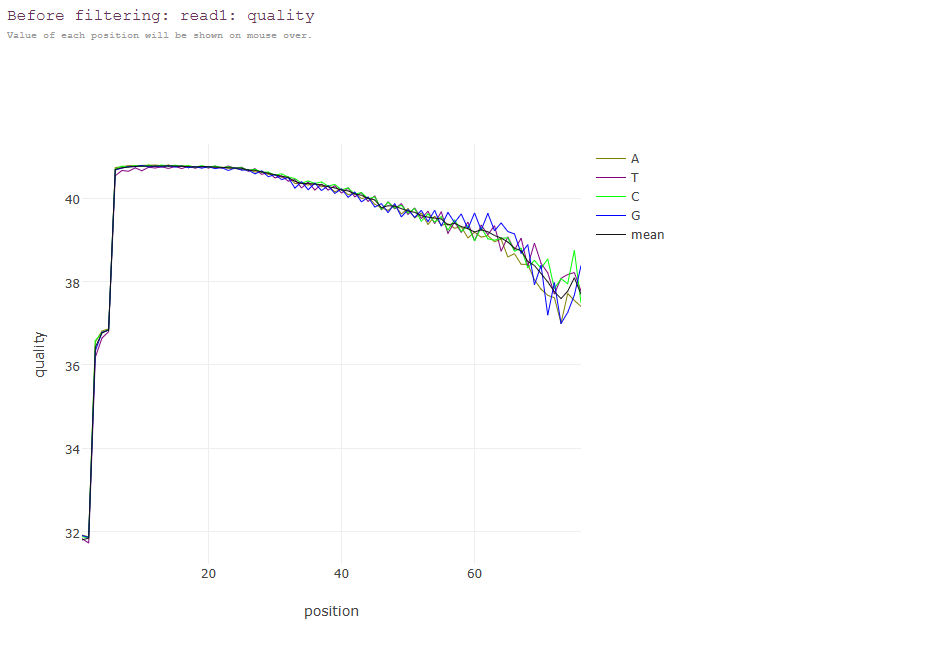

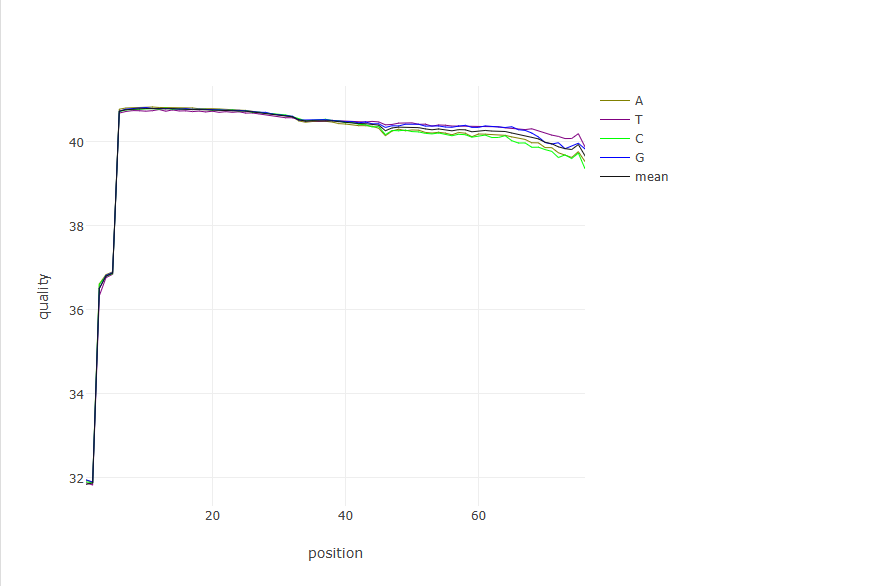

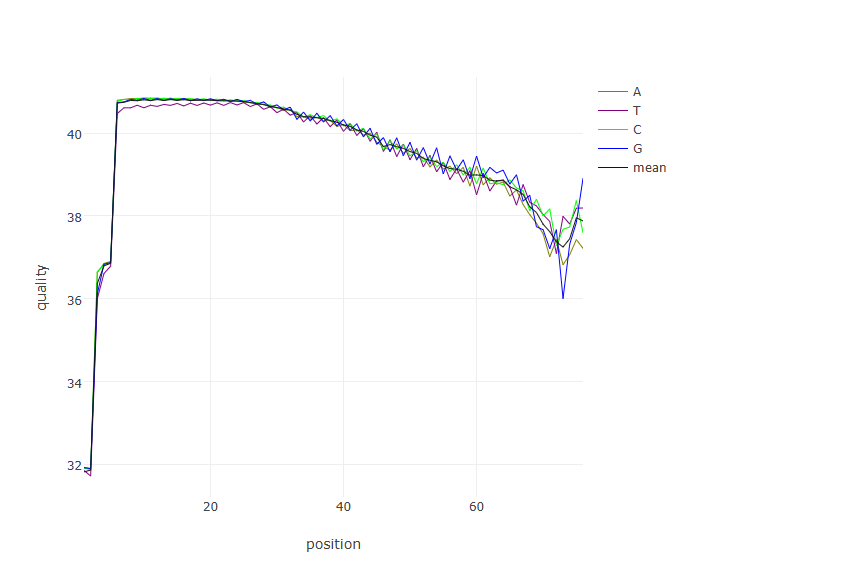

## 3. Тримминг данных (fastp)
Для очистки использовалась программа **fastp**, которая за один проход выполняет поиск/удаление адаптеров, обрезку по качеству и фильтрацию коротких прочтений. Встроенный функционал позволил одновременно получить отчеты до и после обработки.

Были удалены:
* Риды с нераспознанными нуклеотидами (N).
* Технические последовательности адаптеров.
* Слишком короткие риды, не несущие полезной биологической информации (основная причина потери данных).

## 4. Контроль качества после фильтрации (Cleaned Data)
После проведения тримминга качество данных во всех трех образцах заметно улучшилось. Все метрики Phred Score стабилизировались, а технический шум был отфильтрован.

**Статистика выживаемости и качества:**
* **ERR14230582:** Прошло 396.1 тыс. ридов (**68.70%**) | Q30: 98.96% | Ср. длина выросла до 44 bp
* **ERR14230586:** Прошло 1.450 млн. ридов (**79.40%**) | Q30: 99.17% | Ср. длина выросла до 47 bp
* **ERR14230595:** Прошло 791.9 тыс. ридов (**70.16%**) | Q30: 99.05% | Ср. длина выросла до 44 bp

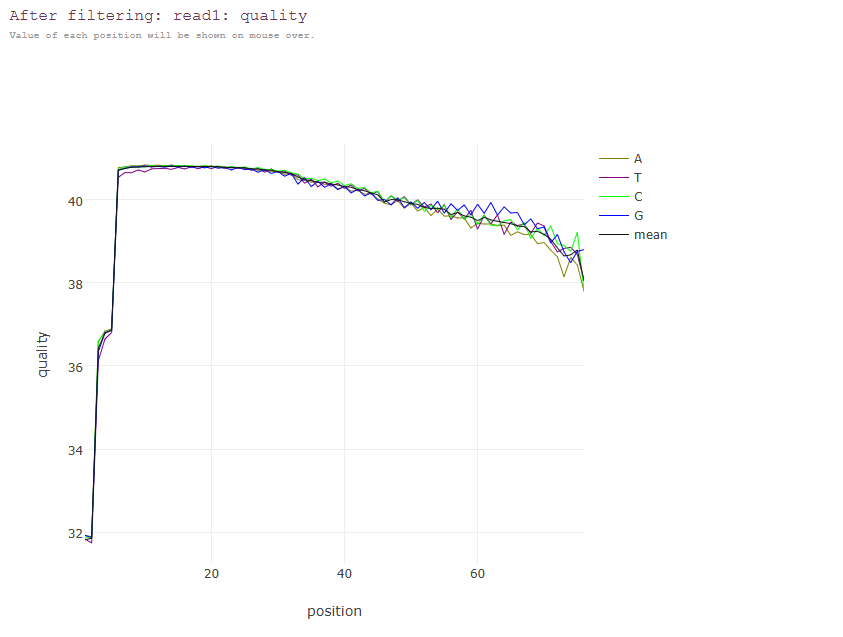

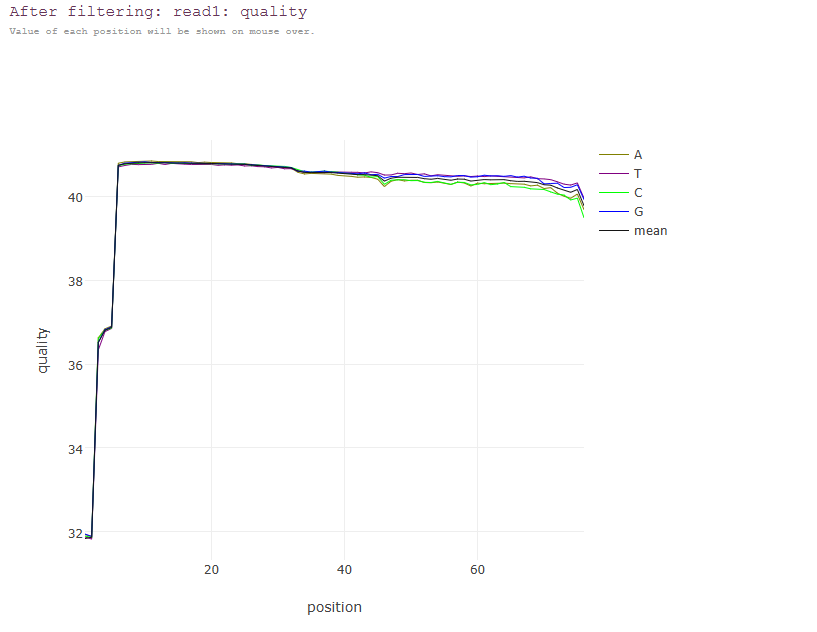

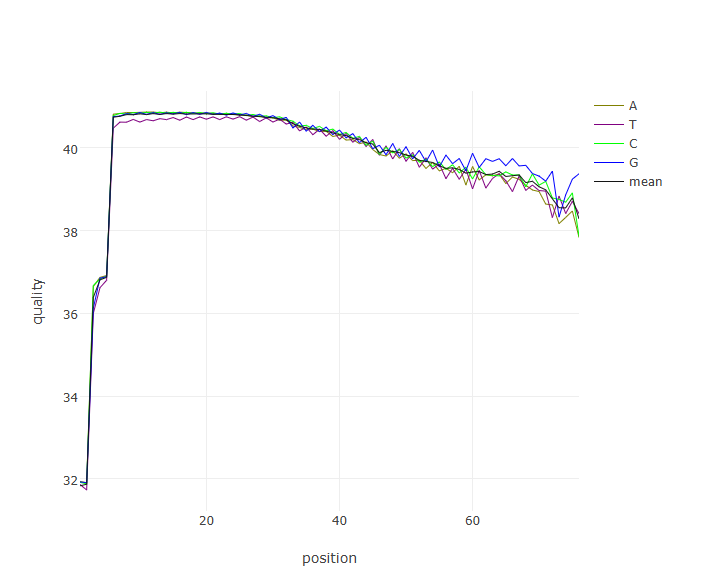

## 5. Вывод
Предобработка сырых библиотек секвенирования прошла успешно. Использование `fastp` позволило эффективно убрать короткие мусорные фрагменты (20-31% от всей выборки) и остатки адаптеров. Качество оставшихся нуклеотидов (Q20/Q30) поднялось до отличных показателей (>99%).